## **Bank Customer Churn Prediction Application**

### **Overview**
This is a machine learning application that predicts whether bank customers are likely to leave (churn) the bank. 
It uses customer demographic and behavioral data to identify at-risk customers and understand the key factors driving customer attrition.

### **Key Features**

**Data Processing:**
- Loads bank customer data from Kaggle (Customer-Churn-Records dataset)
- Cleans data by removing irrelevant columns (RowNumber, CustomerId, Surname)
- Handles categorical variables (Geography, Gender, Card Type) through one-hot encoding
- Addresses class imbalance using SMOTE (Synthetic Minority Oversampling Technique)

**Exploratory Data Analysis:**
- Visualizes target variable distribution (Exited vs Retained customers)
- Calculates churn rate percentage
- Analyzes feature-target correlations through correlation matrix and heatmap
- Performs chi-square tests for categorical feature significance

**Machine Learning Models:**
The app trains and compares **5 different classification models**:
1. **Logistic Regression** - Fast baseline model
2. **K-Nearest Neighbors (KNN)** - Instance-based learning approach
3. **Random Forest** - Ensemble method for improved accuracy
4. **Support Vector Machine (SVM)** with RBF kernel
5. **Support Vector Machine (SVM)** with Polynomial kernel

**Performance Evaluation:**
- Compares models using multiple metrics: Accuracy, Precision, Recall, F1-Score, ROC-AUC
- Generates confusion matrices for each model
- Creates a comprehensive comparison table to identify the best-performing model

**Use Case:**
Banks can use this model to:
- Identify customers at high risk of leaving
- Prioritize retention efforts
- Understand which factors most influence customer churn
- Optimize customer relationship management strategies

In [2]:
import kagglehub

c:\Users\Chandra Sekhar\AI Leadership Transition\venv_tf\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# download the dataset and print the path to the downloaded file
# the dataset is "radheshyamkollipara/bank-customer-churn" and it is a csv file
path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")
print(path)

C:\Users\Chandra Sekhar\.cache\kagglehub\datasets\radheshyamkollipara\bank-customer-churn\versions\1


In [4]:
import pandas as pd
import numpy as np

# read the csv file into a pandas dataframe. 
# it is also important to understand the data before we can start working on it.
# look at the first 5 rows of the dataframe to understand the structure of the data.
# see if there are any missing values in the dataframe and how to handle them.

df = pd.read_csv(path + "/Customer-Churn-Records.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [5]:
def drop_columns(df, columns):
    return df.drop(columns=columns)

# always drop the columns which are not useful for our analysis and model building.
# We can see that the columns "RowNumber", "CustomerId", "Surname" are not useful 
# for our analysis and model building. So we will drop these columns from the dataframe.
columns_to_drop = ["RowNumber", "CustomerId", "Surname"]
df = drop_columns(df, columns_to_drop)

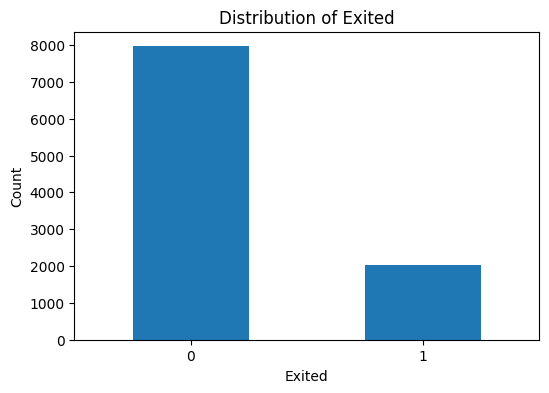

In [6]:

# Plot the distribution of the target variable "Exited" to understand the 
# class imbalance in the dataset. This will help us to decide if we need to use 
# any techniques to handle the class imbalance in the dataset.
# 
# Class imbalance is a common problem in machine learning where the number of samples 
# in one class is significantly higher than the number of samples in the other class. 
# This can lead to biased models that perform well on the majority class but poorly on 
# the minority class. Therefore, it is important to understand the distribution of the 
# target variable before building a model.
# 
# We can see that the target variable "Exited" is imbalanced with more number of
# customers who have not exited the bank. This means that we need to use some
# techniques to handle the class imbalance in the dataset.
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
df["Exited"].value_counts().plot(kind="bar")
plt.title("Distribution of Exited")
plt.xlabel("Exited")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [7]:
# Calculate the percentage of customers who exited the bank. 
# This will give us an idea of how many customers we are losing and 
# how important it is to build a model to predict customer churn.
# The percentage of customers who exited the bank is an important metric to understand
# the severity of the churn problem. If the percentage is high, it indicates that a
# significant portion of customers are leaving the bank, which can have a negative impact
# on the bank's revenue and profitability. On the other hand, if the percentage is low,
# it may indicate that the churn problem is not as severe, but it is still important to
# build a model to predict customer churn in order to retain customers and improve the
# bank's performance.

exited_percentage = df["Exited"].mean() * 100
print(f"Percentage of customers who exited: {exited_percentage:.2f}%")


Percentage of customers who exited: 20.38%


In [8]:
# Calculate the correlation matrix to understand the relationship between the features and the target variable "Exited".
# This will help us to identify the features that are most correlated with the target variable and can be used for building the model.
# The correlation matrix is a table that shows the correlation coefficients between the features and the target variable. 
# The correlation coefficient ranges from -1 to 1, where -1 indicates a perfect negative correlation, 0 indicates no correlation, 
# and 1 indicates a perfect positive correlation. By analyzing the correlation matrix, we can identify which features are most strongly 
# correlated with the target variable "Exited" and can be used for building the model. 
# This can help us to improve the performance of the model by selecting the most relevant features. 

correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix["Exited"].sort_values(ascending=False))


Exited                1.000000
Complain              0.995693
Age                   0.285296
Balance               0.118577
EstimatedSalary       0.012490
Point Earned         -0.004628
Satisfaction Score   -0.005849
HasCrCard            -0.006976
Tenure               -0.013656
CreditScore          -0.026771
NumOfProducts        -0.047611
IsActiveMember       -0.156356
Name: Exited, dtype: float64


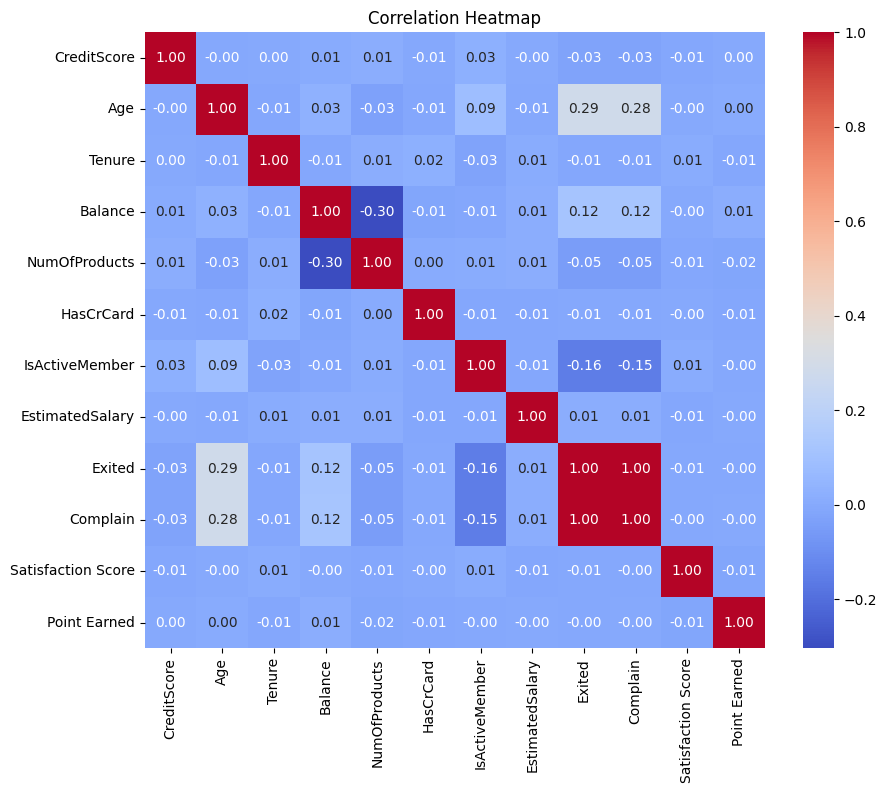

In [9]:
# Visualize the correlation matrix using a heatmap to better understand the relationships between the features and the target variable "Exited".

# Becuasae the correlation matrix is a large table, it can be difficult to understand the relationships between the features and 
# the target variable "Exited" just by looking at the numbers. A heatmap is a graphical representation of the correlation matrix where the 
# values are represented by colors. This can help us to quickly identify which features are most strongly correlated with the target variable "Exited" and 
# can be used for building the model. The heatmap can also help us to identify any patterns or trends in the data that may not be immediately 
# apparent from the correlation matrix alone.

# but we have only 20% of customer exited the bank, so we need to be careful while interpreting the correlation matrix and heatmap.
# Here we can see that the features "CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "HasCrCard", "IsActiveMember" are negatively 
# correlated with the target variable "Exited". While the features "EstimatedSalary" is positively correlated with the target variable "Exited". 
# This means that customers with higher credit scores, older age, longer tenure, higher balance, more products, having a credit card, 
# and being an active member are less likely to exit the bank.

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [10]:
# The chi-square test is used to determine if there is a significant association between categorical variables and the target variable. 
#
# In this case, we can use the chi-square test to determine if there is a significant association between the categorical features 
# "Geography", "Gender", "Card Type" and the target variable "Exited".
from scipy.stats import chi2_contingency
categorical_features = ["Geography", "Gender", "Card Type"]
for feature in categorical_features:
    contingency_table = pd.crosstab(df[feature], df["Exited"])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"Chi-square test for {feature}:")
    print(f"Chi2 statistic: {chi2:.2f}, p-value: {p:.4f}")
    print("-" * 30)
    

Chi-square test for Geography:
Chi2 statistic: 300.63, p-value: 0.0000
------------------------------
Chi-square test for Gender:
Chi2 statistic: 112.40, p-value: 0.0000
------------------------------
Chi-square test for Card Type:
Chi2 statistic: 5.05, p-value: 0.1679
------------------------------


In [ ]:
# convert categorical features to dummy variables 
# Dummy variables are binary variables that indicate the presence or absence of a categorical feature.
# For example, if we have a categorical feature "Gender" with three categories "Male", "Female", "Other", we can create three 
# dummy variables "Gender_Male", "Gender_Female", "Gender_Other". This will allow us to use these categorical features in our machine learning model, 
#  as most models require numerical input.
categorical_features = ["Geography", "Gender", "Card Type"]
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  int64  
 1   Age                 10000 non-null  int64  
 2   Tenure              10000 non-null  int64  
 3   Balance             10000 non-null  float64
 4   NumOfProducts       10000 non-null  int64  
 5   HasCrCard           10000 non-null  int64  
 6   IsActiveMember      10000 non-null  int64  
 7   EstimatedSalary     10000 non-null  float64
 8   Exited              10000 non-null  int64  
 9   Complain            10000 non-null  int64  
 10  Satisfaction Score  10000 non-null  int64  
 11  Point Earned        10000 non-null  int64  
 12  Geography_Germany   10000 non-null  bool   
 13  Geography_Spain     10000 non-null  bool   
 14  Gender_Male         10000 non-null  bool   
 15  Card Type_GOLD      10000 non-null  bool   
 16  Card Type_PLATIN

In [36]:
# Now that we have prepared the data, we can split the data into features and target variable.
# The features are the independent variables that we will use to predict the target variable "Exited".
# The target variable "Exited" is the dependent variable that we want to predict.
# Drop the leakage features "Complain" and "Satisfaction Score" if drop_leakage_features is set to True. 
# Leakage features are features that are highly correlated with the target variable and can lead to overfitting of the model. 
# For example, if we have a feature "Complain" that indicates whether a customer has complained about the bank's services, 
# it is likely to be highly correlated with the target variable "Exited".
def prepare_data(df, drop_leakage_features=False, leakage_features=["Complain"]):
    features_columns = [col for col in df.columns if col != "Exited"]
    target_column = "Exited"
    if drop_leakage_features:
        features_columns = [col for col in features_columns if col not in leakage_features]

    X = df[features_columns]
    y = df[target_column]
    return X, y


In [ ]:
# Split the data into features and target variable
X, y = prepare_data(df)

In [ ]:
# Split the data into training and testing sets to evaluate the performance of the model.
# We will use 80% of the data for training the model and 20% of the data for testing the model.
# random_state is set to 42 to ensure that the results are reproducible. This means that every time we run the code, 
# we will get the same split of the data into training and testing sets.
def split_data(X, y, test_size=0.2, random_state=42):
    from sklearn.model_selection import train_test_split
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

X_train, X_test, y_train, y_test = split_data(X, y)

In [ ]:
# SMOTE (Synthetic Minority Over-sampling Technique) is a technique used to handle class imbalance in the dataset.
# It works by creating synthetic samples of the minority class to balance the dataset.
# Since we have only 20% of customers who exited the bank, we have a class imbalance problem in our dataset.
# This can lead to biased models that perform well on the majority class (customers who did not exit) but poorly on the minority class (customers who exited). 
# To handle this class imbalance, we can use SMOTE to create synthetic samples of the minority class (customers who exited) 
# to balance the dataset and improve the performance of our model.    
def smote_oversampling(X_train, y_train):
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    return X_train_resampled, y_train_resampled

In [ ]:

# Evaluate the performance of the model using various metrics such as accuracy, precision, recall, F1 score, ROC-AUC score, and confusion matrix.
# evaluate performance metrics for classification models. Model is parameterized to accept any classification model and return the performance metrics.
# roc-auc score, accuracy, precision, recall, f1-score, confusion matrix

def evaluate_model(model, X_test, y_test):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
    from sklearn.metrics import roc_auc_score

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)
    return accuracy, precision, recall, f1, roc_auc, conf_matrix

In [ ]:
# define a function to train a logistic regression model. 
# Logistic regression is a commonly used classification algorithm that is used to predict the probability of a binary outcome.
def train_logistic_regression(X_train, y_train):
    from sklearn.linear_model import LogisticRegression
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    return model

In [ ]:
# define a function to train KNN classifier 
# KNN (K-Nearest Neighbors) is a simple and effective classification algorithm that is based on the principle of "birds of a feather flock together".
def train_knn(X_train, y_train, n_neighbors=5):
    from sklearn.neighbors import KNeighborsClassifier
    model = KNeighborsClassifier(n_neighbors=n_neighbors)
    model.fit(X_train, y_train)
    return model

In [ ]:
# def functions to train Random Forest and SVM classifiers
# Random Forest is an ensemble learning method that combines multiple decision trees to improve the performance of the model.
# SVM (Support Vector Machine) is a powerful classification algorithm that finds the optimal hyperplane that separates the classes in the feature space.
def train_random_forest(X_train, y_train, n_estimators=100):
    from sklearn.ensemble import RandomForestClassifier
    model = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    model.fit(X_train, y_train)
    return model

def train_svm(X_train, y_train, kernel="rbf"):
    from sklearn.svm import SVC
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train, y_train)
    return model

In [21]:

# call logistic regression model and evaluate its performance
logistic_model = train_logistic_regression(X_train, y_train)
accuracy_lr, precision_lr, recall_lr, f1_lr, roc_auc_lr, conf_matrix_lr = evaluate_model(logistic_model, X_test, y_test)

# call KNN model and evaluate its performance
knn_model = train_knn(X_train, y_train, n_neighbors=5)
accuracy_knn, precision_knn, recall_knn, f1_knn, roc_auc_knn, conf_matrix_knn = evaluate_model(knn_model, X_test, y_test)

# call Random Forest model and evaluate its performance
rf_model = train_random_forest(X_train, y_train)
accuracy_rf, precision_rf, recall_rf, f1_rf, roc_auc_rf, conf_matrix_rf = evaluate_model(rf_model, X_test, y_test)

# call SVM model and evaluate its performance
svm_model = train_svm(X_train, y_train, kernel="rbf")
accuracy_svm_rbf, precision_svm_rbf, recall_svm_rbf, f1_svm_rbf, roc_auc_svm_rbf, conf_matrix_svm_rbf = evaluate_model(svm_model, X_test, y_test)

# call SVM model with linear kernel and evaluate its performance
# svm_model_linear = train_svm(X_train, y_train, kernel="linear")
#accuracy_svm_linear, precision_svm_linear, recall_svm_linear, f1_svm_linear, roc_auc_svm_linear, conf_matrix_svm_linear = evaluate_model(svm_model_linear, X_test, y_test)

# call SVM model with polynomial kernel and evaluate its performance
svm_model_poly = train_svm(X_train, y_train, kernel="poly")
accuracy_svm_poly, precision_svm_poly, recall_svm_poly, f1_svm_poly, roc_auc_svm_poly, conf_matrix_svm_poly = evaluate_model(svm_model_poly, X_test, y_test)


c:\Users\Chandra Sekhar\AI Leadership Transition\venv_tf\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.9985
Precision: 0.9974
Recall: 0.9949
F1 Score: 0.9962
ROC-AUC Score: 0.9971
Confusion Matrix:
[[1606    1]
 [   2  391]]
Accuracy: 0.7650
Precision: 0.2416
Recall: 0.0916
F1 Score: 0.1328
ROC-AUC Score: 0.5106
Confusion Matrix:
[[1494  113]
 [ 357   36]]
Accuracy: 0.9990
Precision: 0.9975
Recall: 0.9975
F1 Score: 0.9975
ROC-AUC Score: 0.9984
Confusion Matrix:
[[1606    1]
 [   1  392]]


c:\Users\Chandra Sekhar\AI Leadership Transition\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy: 0.8035
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC-AUC Score: 0.5000
Confusion Matrix:
[[1607    0]
 [ 393    0]]
Accuracy: 0.8035
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC-AUC Score: 0.5000
Confusion Matrix:
[[1607    0]
 [ 393    0]]


c:\Users\Chandra Sekhar\AI Leadership Transition\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
# create comparison table for the performance metrics of all the models. 
# This will help us to compare the performance of all the models and select the best model for our problem.
comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "KNN", "SVM (RBF)", "SVM (Polynomial)"],
    "Accuracy": [accuracy_lr, accuracy_rf, accuracy_knn, accuracy_svm_rbf, accuracy_svm_poly],
    "Precision": [precision_lr, precision_rf, precision_knn, precision_svm_rbf, precision_svm_poly],
    "Recall": [recall_lr, recall_rf, recall_knn, recall_svm_rbf, recall_svm_poly],
    "F1-Score": [f1_lr, f1_rf, f1_knn, f1_svm_rbf, f1_svm_poly],
    "ROC-AUC": [roc_auc_lr, roc_auc_rf, roc_auc_knn, roc_auc_svm_rbf, roc_auc_svm_poly]
})

print(comparison_table)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression    0.9985   0.997449  0.994911  0.996178  0.997144
1        Random Forest    0.9990   0.997455  0.997455  0.997455  0.998417
2                  KNN    0.7650   0.241611  0.091603  0.132841  0.510643
3            SVM (RBF)    0.8035   0.000000  0.000000  0.000000  0.500000
4     SVM (Polynomial)    0.8035   0.000000  0.000000  0.000000  0.500000


In [ ]:
# Now we will use SMOTE to handle the class imbalance in the dataset and evaluate the performance of the models on the resampled data.

X_train_resampled, y_train_resampled = smote_oversampling(X_train, y_train)
# call logistic regression model on resampled data and evaluate its performance
logistic_model_resampled = train_logistic_regression(X_train_resampled, y_train_resampled)
accuracy_lr_resampled, precision_lr_resampled, recall_lr_resampled, f1_lr_resampled, roc_auc_lr_resampled, conf_matrix_lr_resampled = evaluate_model(logistic_model_resampled, X_test, y_test)  

# call KNN model on resampled data and evaluate its performance
knn_model_resampled = train_knn(X_train_resampled, y_train_resampled, n_neighbors=5)
accuracy_knn_resampled, precision_knn_resampled, recall_knn_resampled, f1_knn_resampled, roc_auc_knn_resampled, conf_matrix_knn_resampled = evaluate_model(knn_model_resampled, X_test, y_test) 

# call Random Forest model on resampled data and evaluate its performance
rf_model_resampled = train_random_forest(X_train_resampled, y_train_resampled)
accuracy_rf_resampled, precision_rf_resampled, recall_rf_resampled, f1_rf_resampled, roc_auc_rf_resampled, conf_matrix_rf_resampled = evaluate_model(rf_model_resampled, X_test, y_test)    
# call SVM model on resampled data and evaluate its performance
svm_model_resampled = train_svm(X_train_resampled, y_train_resampled, kernel="rbf")
accuracy_svm_rbf_resampled, precision_svm_rbf_resampled, recall_svm_rbf_resampled, f1_svm_rbf_resampled, roc_auc_svm_rbf_resampled, conf_matrix_svm_rbf_resampled = evaluate_model(svm_model_resampled, X_test, y_test) 
# call SVM model with polynomial kernel on resampled data and evaluate its performance
svm_model_poly_resampled = train_svm(X_train_resampled, y_train_resampled, kernel="poly")
accuracy_svm_poly_resampled, precision_svm_poly_resampled, recall_svm_poly_resampled, f1_svm_poly_resampled, roc_auc_svm_poly_resampled, conf_matrix_svm_poly_resampled = evaluate_model(svm_model_poly_resampled, X_test, y_test)

c:\Users\Chandra Sekhar\AI Leadership Transition\venv_tf\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.9920
Precision: 0.9922
Recall: 0.9669
F1 Score: 0.9794
ROC-AUC Score: 0.9825
Confusion Matrix:
[[1604    3]
 [  13  380]]
Accuracy: 0.5655
Precision: 0.2083
Recall: 0.4326
F1 Score: 0.2812
ROC-AUC Score: 0.5153
Confusion Matrix:
[[961 646]
 [223 170]]
Accuracy: 0.9990
Precision: 0.9975
Recall: 0.9975
F1 Score: 0.9975
ROC-AUC Score: 0.9984
Confusion Matrix:
[[1606    1]
 [   1  392]]
Accuracy: 0.4520
Precision: 0.2290
Recall: 0.7557
F1 Score: 0.3515
ROC-AUC Score: 0.5667
Confusion Matrix:
[[ 607 1000]
 [  96  297]]
Accuracy: 0.6500
Precision: 0.2367
Recall: 0.3511
F1 Score: 0.2828
ROC-AUC Score: 0.5371
Confusion Matrix:
[[1162  445]
 [ 255  138]]


In [24]:
# create comparison table for the performance metrics of all the models on resampled data
comparison_table_resampled = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Random Forest', 'SVM (RBF)', 'SVM (Polynomial)'],
    'Accuracy': [accuracy_lr_resampled, accuracy_knn_resampled, accuracy_rf_resampled, accuracy_svm_rbf_resampled, accuracy_svm_poly_resampled],
    'Precision': [precision_lr_resampled, precision_knn_resampled, precision_rf_resampled, precision_svm_rbf_resampled, precision_svm_poly_resampled],
    'Recall': [recall_lr_resampled, recall_knn_resampled, recall_rf_resampled, recall_svm_rbf_resampled, recall_svm_poly_resampled],
    'F1-Score': [f1_lr_resampled, f1_knn_resampled, f1_rf_resampled, f1_svm_rbf_resampled, f1_svm_poly_resampled],
    'ROC-AUC': [roc_auc_lr_resampled, roc_auc_knn_resampled, roc_auc_rf_resampled, roc_auc_svm_rbf_resampled, roc_auc_svm_poly_resampled]
})
print(comparison_table_resampled)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression    0.9920   0.992167  0.966921  0.979381  0.982527
1                  KNN    0.5655   0.208333  0.432570  0.281224  0.515289
2        Random Forest    0.9990   0.997455  0.997455  0.997455  0.998417
3            SVM (RBF)    0.4520   0.228990  0.755725  0.351479  0.566724
4     SVM (Polynomial)    0.6500   0.236707  0.351145  0.282787  0.537116


In [34]:
# print the comparison table for the performance metrics of all the models on original data and 
# resampled data to compare the performance of the models before and after handling the class imbalance using SMOTE.
print("Comparison of model performance before handling class imbalance using SMOTE:")
print(comparison_table)

print("\n\nComparison of model performance after handling class imbalance using SMOTE:")

print(comparison_table_resampled)

Comparison of model performance before handling class imbalance using SMOTE:
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression    0.9985   0.997449  0.994911  0.996178  0.997144
1        Random Forest    0.9990   0.997455  0.997455  0.997455  0.998417
2                  KNN    0.7650   0.241611  0.091603  0.132841  0.510643
3            SVM (RBF)    0.8035   0.000000  0.000000  0.000000  0.500000
4     SVM (Polynomial)    0.8035   0.000000  0.000000  0.000000  0.500000


Comparison of model performance after handling class imbalance using SMOTE:
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression    0.9920   0.992167  0.966921  0.979381  0.982527
1                  KNN    0.5655   0.208333  0.432570  0.281224  0.515289
2        Random Forest    0.9990   0.997455  0.997455  0.997455  0.998417
3            SVM (RBF)    0.4520   0.228990  0.755725  0.351479  0.566724
4     SVM (Polynomial)    0.650

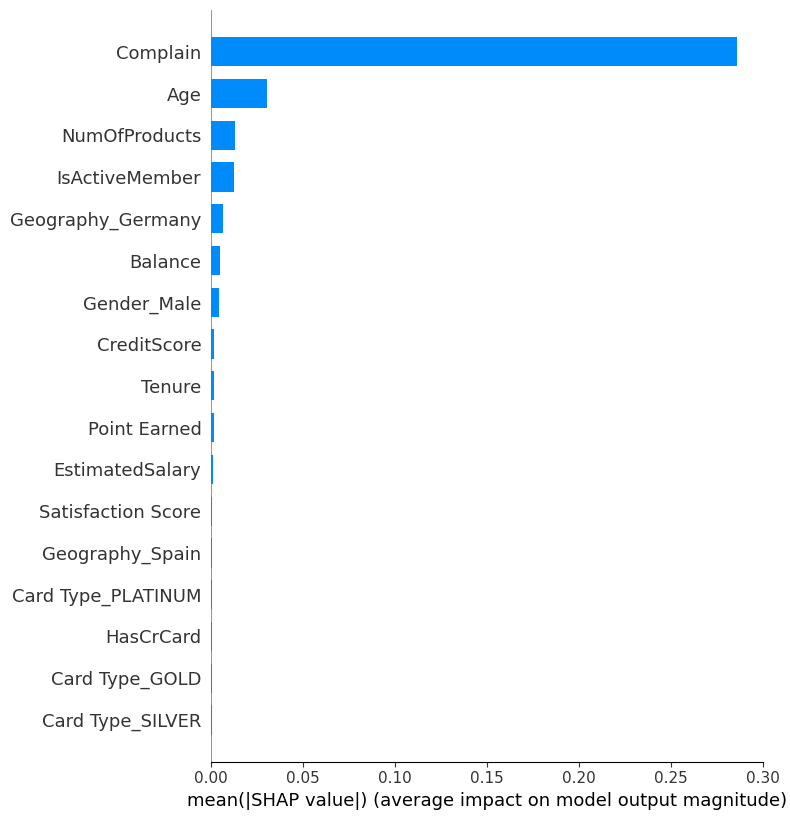

               Feature  Importance
8             Complain    0.825072
1                  Age    0.065798
4        NumOfProducts    0.042478
6       IsActiveMember    0.012948
3              Balance    0.011474
0          CreditScore    0.007763
11   Geography_Germany    0.007479
7      EstimatedSalary    0.007362
10        Point Earned    0.006568
2               Tenure    0.003969
13         Gender_Male    0.002686
9   Satisfaction Score    0.002505
12     Geography_Spain    0.000995
14      Card Type_GOLD    0.000826
5            HasCrCard    0.000773
16    Card Type_SILVER    0.000701
15  Card Type_PLATINUM    0.000605


In [ ]:
# find why customer chrun and which features are important 
# To find the possible reasons for customer churn and which features are important in predicting customer churn, we can use the feature 
# importance from the Random Forest model.    

import shap

# SHAP (SHapley Additive exPlanations) is a method to explain the output of machine learning models. 
# It assigns each feature an importance value for a particular prediction.   
# explain the feature importance using SHAP values for the Random Forest model
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values[:,:,1], X_test, plot_type="bar")

# get feature importance from the Random Forest model
importance = rf_model.feature_importances_

# feature importance df
feature_importance_df = pd.DataFrame({
    "Feature" : X_train.columns,
    "Importance" : importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)

# Clearly the most important feature is Complains, which dominates the feature importance. 
# This is because customers who have complained about the bank's services are more likely to exit the bank.

In [40]:
# Now we need to see are there any feature that is impacting customer churn and evaluate the performance of the models again after 
# dropping the leakage features "Complain".
X, y = prepare_data(df, drop_leakage_features=True, leakage_features=["Complain"])

X_train, X_test, y_train, y_test = split_data(X, y)

# call logistic regression model and evaluate its performance
logistic_lf_model = train_logistic_regression(X_train, y_train)
accuracy_lf_lr, precision_lf_lr, recall_lf_lr, f1_lf_lr, roc_auc_lf_lr, conf_matrix_lf_lr = evaluate_model(logistic_lf_model, X_test, y_test)

# call KNN model and evaluate its performance
knn_lf_model = train_knn(X_train, y_train, n_neighbors=5)
accuracy_lf_knn, precision_lf_knn, recall_lf_knn, f1_lf_knn, roc_auc_lf_knn, conf_matrix_lf_knn = evaluate_model(knn_lf_model, X_test, y_test)

# call Random Forest model and evaluate its performance
rf_lf_model = train_random_forest(X_train, y_train)
accuracy_lf_rf, precision_lf_rf, recall_lf_rf, f1_lf_rf, roc_auc_lf_rf, conf_matrix_lf_rf = evaluate_model(rf_lf_model, X_test, y_test)

# call SVM model and evaluate its performance
svm_lf_model = train_svm(X_train, y_train, kernel="rbf")
accuracy_svm_lf_rbf, precision_svm_lf_rbf, recall_svm_lf_rbf, f1_svm_lf_rbf, roc_auc_svm_lf_rbf, conf_matrix_svm_lf_rbf = evaluate_model(svm_lf_model, X_test, y_test)

# call SVM model with linear kernel and evaluate its performance
# svm_lf_model_linear = train_svm(X_train, y_train, kernel="linear")
#accuracy_svm_lf_linear, precision_svm_lf_linear, recall_svm_lf_linear, f1_svm_lf_linear, roc_auc_svm_lf_linear, conf_matrix_svm_lf_linear = evaluate_model(svm_lf_model_linear, X_test, y_test)

# call SVM model with polynomial kernel and evaluate its performance
svm_lf_model_poly = train_svm(X_train, y_train, kernel="poly")
accuracy_svm_lf_poly, precision_svm_lf_poly, recall_svm_lf_poly, f1_svm_lf_poly, roc_auc_svm_lf_poly, conf_matrix_svm_lf_poly = evaluate_model(svm_lf_model_poly, X_test, y_test)

c:\Users\Chandra Sekhar\AI Leadership Transition\venv_tf\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8150
Precision: 0.5782
Recall: 0.2163
F1 Score: 0.3148
ROC-AUC Score: 0.5889
Confusion Matrix:
[[1545   62]
 [ 308   85]]
Accuracy: 0.7650
Precision: 0.2416
Recall: 0.0916
F1 Score: 0.1328
ROC-AUC Score: 0.5106
Confusion Matrix:
[[1494  113]
 [ 357   36]]
Accuracy: 0.8655
Precision: 0.7583
Recall: 0.4631
F1 Score: 0.5750
ROC-AUC Score: 0.7135
Confusion Matrix:
[[1549   58]
 [ 211  182]]


c:\Users\Chandra Sekhar\AI Leadership Transition\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy: 0.8035
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC-AUC Score: 0.5000
Confusion Matrix:
[[1607    0]
 [ 393    0]]
Accuracy: 0.8035
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC-AUC Score: 0.5000
Confusion Matrix:
[[1607    0]
 [ 393    0]]


c:\Users\Chandra Sekhar\AI Leadership Transition\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [41]:
# comparison of model performance after dropping leakage features
comparison_table_lf = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Random Forest", "SVM (RBF)", "SVM (Polynomial)"],
    "Accuracy": [accuracy_lf_lr, accuracy_lf_knn, accuracy_lf_rf, accuracy_svm_lf_rbf, accuracy_svm_lf_poly],
    "Precision": [precision_lf_lr, precision_lf_knn, precision_lf_rf, precision_svm_lf_rbf, precision_svm_lf_poly],
    "Recall": [recall_lf_lr, recall_lf_knn, recall_lf_rf, recall_svm_lf_rbf, recall_svm_lf_poly],
    "F1-Score": [f1_lf_lr, f1_lf_knn, f1_lf_rf, f1_svm_lf_rbf, f1_svm_lf_poly],
    "ROC-AUC": [roc_auc_lf_lr, roc_auc_lf_knn, roc_auc_lf_rf, roc_auc_svm_lf_rbf, roc_auc_svm_lf_poly]
})

# print comparison table
print(comparison_table_lf)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression    0.8150   0.578231  0.216285  0.314815  0.588852
1                  KNN    0.7650   0.241611  0.091603  0.132841  0.510643
2        Random Forest    0.8655   0.758333  0.463104  0.575039  0.713506
3            SVM (RBF)    0.8035   0.000000  0.000000  0.000000  0.500000
4     SVM (Polynomial)    0.8035   0.000000  0.000000  0.000000  0.500000


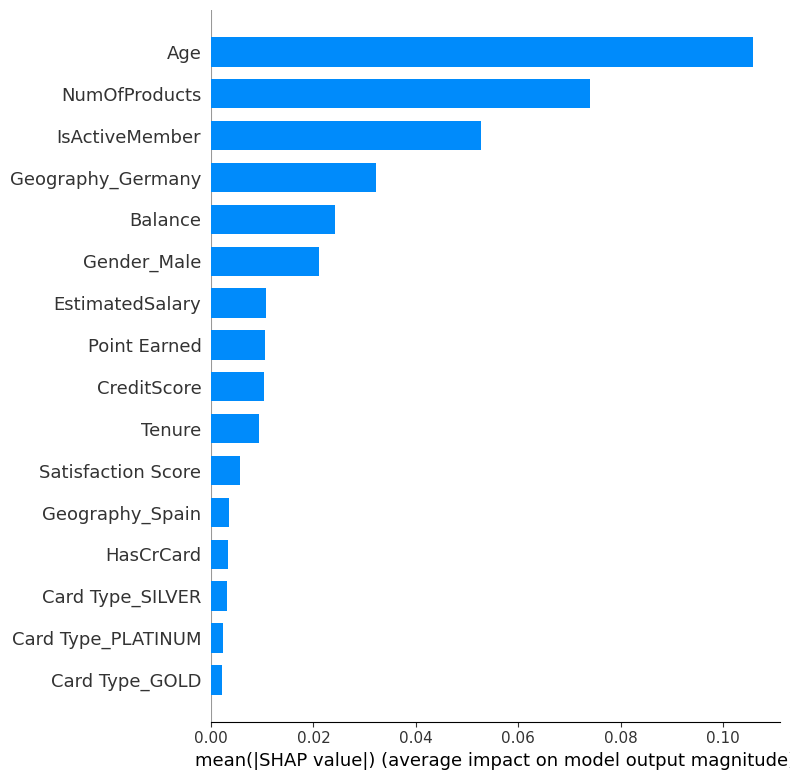

               Feature  Importance
1                  Age    0.215842
4        NumOfProducts    0.123072
3              Balance    0.106918
7      EstimatedSalary    0.105188
9         Point Earned    0.102252
0          CreditScore    0.102026
2               Tenure    0.060528
8   Satisfaction Score    0.039869
6       IsActiveMember    0.039443
10   Geography_Germany    0.024197
12         Gender_Male    0.016956
5            HasCrCard    0.014773
14  Card Type_PLATINUM    0.013091
15    Card Type_SILVER    0.012900
13      Card Type_GOLD    0.012240
11     Geography_Spain    0.010705


In [42]:

# shap values for the Random Forest model after dropping leakage features
explainer = shap.TreeExplainer(rf_lf_model)
shap_lf_values = explainer.shap_values(X_test)
shap.summary_plot(shap_lf_values[:,:,1], X_test, plot_type="bar")

# feature importance df
importance_lf = rf_lf_model.feature_importances_

feature_importance_lf_df = pd.DataFrame({
    "Feature" : X_train.columns,
    "Importance" : importance_lf
}).sort_values(by="Importance", ascending=False)

print(feature_importance_lf_df)




c:\Users\Chandra Sekhar\AI Leadership Transition\venv_tf\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8150
Precision: 0.5793
Recall: 0.2137
F1 Score: 0.3123
ROC-AUC Score: 0.5879
Confusion Matrix:
[[1546   61]
 [ 309   84]]
Accuracy: 0.7650
Precision: 0.2416
Recall: 0.0916
F1 Score: 0.1328
ROC-AUC Score: 0.5106
Confusion Matrix:
[[1494  113]
 [ 357   36]]
Accuracy: 0.8680
Precision: 0.7768
Recall: 0.4606
F1 Score: 0.5783
ROC-AUC Score: 0.7141
Confusion Matrix:
[[1555   52]
 [ 212  181]]


c:\Users\Chandra Sekhar\AI Leadership Transition\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy: 0.8035
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC-AUC Score: 0.5000
Confusion Matrix:
[[1607    0]
 [ 393    0]]


c:\Users\Chandra Sekhar\AI Leadership Transition\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy: 0.8035
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC-AUC Score: 0.5000
Confusion Matrix:
[[1607    0]
 [ 393    0]]
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression    0.8150   0.579310  0.213740  0.312268  0.587891
1                  KNN    0.7650   0.241611  0.091603  0.132841  0.510643
2        Random Forest    0.8680   0.776824  0.460560  0.578275  0.714101
3            SVM (RBF)    0.8035   0.000000  0.000000  0.000000  0.500000
4     SVM (Polynomial)    0.8035   0.000000  0.000000  0.000000  0.500000


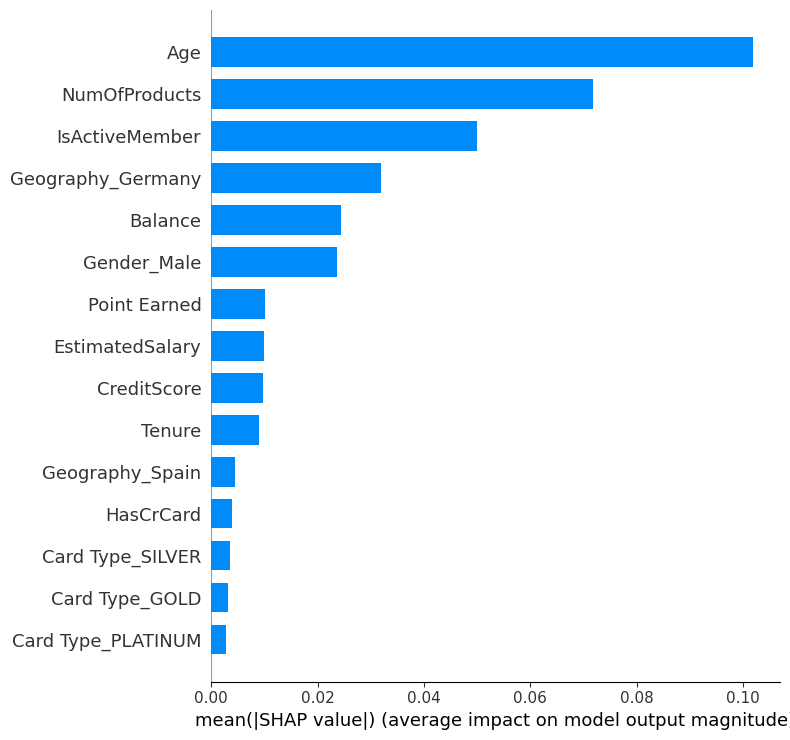

               Feature  Importance
1                  Age    0.216239
4        NumOfProducts    0.124093
3              Balance    0.113608
0          CreditScore    0.110632
7      EstimatedSalary    0.110544
8         Point Earned    0.110476
2               Tenure    0.068696
6       IsActiveMember    0.036999
9    Geography_Germany    0.023922
11         Gender_Male    0.017612
5            HasCrCard    0.015921
14    Card Type_SILVER    0.013681
13  Card Type_PLATINUM    0.013538
12      Card Type_GOLD    0.012686
10     Geography_Spain    0.011353


In [43]:
# Now we need to see are there any feature that is impacting customer churn and evaluate the performance of the models again after 
# dropping the leakage features "Complain" and "Satisfaction Score".
X, y = prepare_data(df, drop_leakage_features=True, leakage_features=["Complain", "Satisfaction Score"])

X_train, X_test, y_train, y_test = split_data(X, y)

# call logistic regression model and evaluate its performance
logistic_lf_model = train_logistic_regression(X_train, y_train)
accuracy_lf_lr, precision_lf_lr, recall_lf_lr, f1_lf_lr, roc_auc_lf_lr, conf_matrix_lf_lr = evaluate_model(logistic_lf_model, X_test, y_test)

# call KNN model and evaluate its performance
knn_lf_model = train_knn(X_train, y_train, n_neighbors=5)
accuracy_lf_knn, precision_lf_knn, recall_lf_knn, f1_lf_knn, roc_auc_lf_knn, conf_matrix_lf_knn = evaluate_model(knn_lf_model, X_test, y_test)

# call Random Forest model and evaluate its performance
rf_lf_model = train_random_forest(X_train, y_train)
accuracy_lf_rf, precision_lf_rf, recall_lf_rf, f1_lf_rf, roc_auc_lf_rf, conf_matrix_lf_rf = evaluate_model(rf_lf_model, X_test, y_test)

# call SVM model and evaluate its performance
svm_lf_model = train_svm(X_train, y_train, kernel="rbf")
accuracy_svm_lf_rbf, precision_svm_lf_rbf, recall_svm_lf_rbf, f1_svm_lf_rbf, roc_auc_svm_lf_rbf, conf_matrix_svm_lf_rbf = evaluate_model(svm_lf_model, X_test, y_test)

# call SVM model with linear kernel and evaluate its performance
# svm_lf_model_linear = train_svm(X_train, y_train, kernel="linear")
#accuracy_svm_lf_linear, precision_svm_lf_linear, recall_svm_lf_linear, f1_svm_lf_linear, roc_auc_svm_lf_linear, conf_matrix_svm_lf_linear = evaluate_model(svm_lf_model_linear, X_test, y_test)

# call SVM model with polynomial kernel and evaluate its performance
svm_lf_model_poly = train_svm(X_train, y_train, kernel="poly")
accuracy_svm_lf_poly, precision_svm_lf_poly, recall_svm_lf_poly, f1_svm_lf_poly, roc_auc_svm_lf_poly, conf_matrix_svm_lf_poly = evaluate_model(svm_lf_model_poly, X_test, y_test)

# comparison of model performance after dropping leakage features
comparison_table_lf = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Random Forest", "SVM (RBF)", "SVM (Polynomial)"],
    "Accuracy": [accuracy_lf_lr, accuracy_lf_knn, accuracy_lf_rf, accuracy_svm_lf_rbf, accuracy_svm_lf_poly],
    "Precision": [precision_lf_lr, precision_lf_knn, precision_lf_rf, precision_svm_lf_rbf, precision_svm_lf_poly],
    "Recall": [recall_lf_lr, recall_lf_knn, recall_lf_rf, recall_svm_lf_rbf, recall_svm_lf_poly],
    "F1-Score": [f1_lf_lr, f1_lf_knn, f1_lf_rf, f1_svm_lf_rbf, f1_svm_lf_poly],
    "ROC-AUC": [roc_auc_lf_lr, roc_auc_lf_knn, roc_auc_lf_rf, roc_auc_svm_lf_rbf, roc_auc_svm_lf_poly]
})

# print comparison table
print(comparison_table_lf)

# shap values for the Random Forest model after dropping leakage features
explainer = shap.TreeExplainer(rf_lf_model)
shap_lf_values = explainer.shap_values(X_test)
shap.summary_plot(shap_lf_values[:,:,1], X_test, plot_type="bar")

# feature importance df
importance_lf = rf_lf_model.feature_importances_

feature_importance_lf_df = pd.DataFrame({
    "Feature" : X_train.columns,
    "Importance" : importance_lf
}).sort_values(by="Importance", ascending=False)

print(feature_importance_lf_df)
